# Open-Ended Section

## Distribution Shift Between Training and Test Data

### 1. Objectives

In this open-ended component, we investigate whether there is a **covariate shift** between the training data (used to tune and select our models) and the test data (used in the Kaggle competition).

Covariate shift occurs when the **distribution of the predictors changes** between train and test, potentially making cross-validation estimates over-optimistic or misleading.

Our objective is to quantify these differences for both **numeric** and **categorical** attributes and to discuss their impact on the robustness and reliability of our final model.

### 2. Methodology

We focus on the features that are available in both datasets (excluding the target `price`, which only exists in the training set, and the variables we ignored since the beggining of the project, since they fall out of the relevant scope - `hasDamage` and `paintQuality%`):

- **Numeric features**: `year`, `mileage`, `tax`, `mpg`, `engineSize`, `previousOwners`
- **Categorical features**: `Brand`, `model`, `transmission`, `fuelType`

The analysis follows three main steps:

1. **Numeric features: summary statistics and KS tests**  
   - For each numeric feature, we compute basic statistics in train vs test (mean, median, standard deviation, quantiles). 
   - We apply the **two-sample Kolmogorov–Smirnov (KS) test** to compare the empirical distributions:
     $$
     H_0: F_{\text{train}}(x) = F_{\text{test}}(x) \quad \forall x
     $$
     A small KS statistic and a large p-value indicate no evidence of distribution shift.

2. **Numeric features: visual comparison**  
   - For each numeric feature, we overlay **normalized histograms / KDEs** of train vs test
   - We visually confirm whether the bulk of the mass and tails overlap.

3. **Categorical features: frequency comparison**  
   - For each categorical feature, we compute the **relative frequency** of each category in train vs. test:
     $$
     p_{\text{train}}(c) = \frac{\#(X_{\text{train}} = c)}{N_{\text{train}}}, \quad
     p_{\text{test}}(c) = \frac{\#(X_{\text{test}} = c)}{N_{\text{test}}}
     $$
   - We then compute the absolute difference $$|p_{\text{train}}(c) - p_{\text{test}}(c)|$$ and rank categories by this value.  
   - This highlights categories whose prevalence changes more strongly between train and test (e.g., brands or typos such as `Toyot` vs `Toyota`).

### 3. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ks_2samp

# Load data
df_train_raw = pd.read_csv("../project_data/train.csv")
df_test_raw  = pd.read_csv("../project_data/test.csv")

# Define feature sets (only features shared by train and test)
target = "price"

num_cols = [
    "year",
    "mileage",
    "tax",
    "mpg",
    "engineSize",
    "previousOwners",
]

cat_cols = [
    "Brand",
    "model",
    "transmission",
    "fuelType",
]

### 4. Numeric Features

#### 4.1. Shift Report (Summary + KS Test)

In [3]:
def numeric_shift_report(train: pd.DataFrame,
                         test: pd.DataFrame,
                         num_cols: list[str]) -> pd.DataFrame:
    """
    Compare numeric feature distributions between train and test using:
    - Means / medians
    - KS statistic and p-value

    Returns a DataFrame sorted by KS statistic (descending).
    """
    rows = []

    for col in num_cols:
        if col not in train.columns or col not in test.columns:
            continue

        tr = train[col].dropna()
        te = test[col].dropna()

        if len(tr) == 0 or len(te) == 0:
            continue

        ks_stat, ks_p = ks_2samp(tr, te)

        rows.append({
            "feature": col,
            "train_mean": tr.mean(),
            "test_mean": te.mean(),
            "mean_diff": te.mean() - tr.mean(),
            "train_median": tr.median(),
            "test_median": te.median(),
            "ks_stat": ks_stat,
            "ks_pvalue": ks_p,
        })

    report = pd.DataFrame(rows)
    report = report.sort_values("ks_stat", ascending=False).reset_index(drop=True)
    return report

numeric_report = numeric_shift_report(df_train_raw, df_test_raw, num_cols)
display(numeric_report)

,feature,train_mean,test_mean,mean_diff,train_median,test_median,ks_stat,ks_pvalue
0,engineSize,1.660136,1.665377,0.005241,1.6,1.6,0.005579,0.487977
1,previousOwners,1.994580,2.006118,0.011538,2.0,2.0,0.005097,0.604666
2,mpg,55.152666,55.210728,0.058062,54.3,54.3,0.004906,0.706193
3,mileage,23004.184088,22952.658921,-51.525167,17300.0,17225.5,0.004469,0.762253
4,year,2017.096611,2017.102299,0.005688,2017.0,2017.0,0.003412,0.956349
5,tax,120.329078,120.569239,0.240162,145.0,145.0,0.002795,0.997094


The table above compares train vs test distributions for our numeric variables using:
- **Mean / median differences** (location shift), and
- The **two-sample Kolmogorov–Smirnov (KS) test** (overall distribution shift).

**Key interpretation:**
- All **KS statistics are extremely small** (from 0.0028 to 0.0056), meaning the empirical distributions of each feature in train and test are *almost identical*.
- All **KS p-values are high** (> 0.05), so we **do not reject** the null hypothesis that train and test come from the same distribution for any numeric feature.
- The **mean and median differences are negligible** in practice:
  - `engineSize`, `previousOwners`, `mpg`, `year`, and `tax` show tiny shifts in central tendency.
  - `mileage` shows the largest mean difference, but it is still small relative to its scale (tens of thousands), and the KS test confirms the overall shape is essentially unchanged.

**Conclusion:**
There is **no evidence of meaningful covariate shift in the numeric features** between the training and test sets. This supports the idea that our cross-validation estimates should transfer reliably to the Kaggle test distribution (at least regarding numeric variables).


#### 4.2. Overlaid Histograms

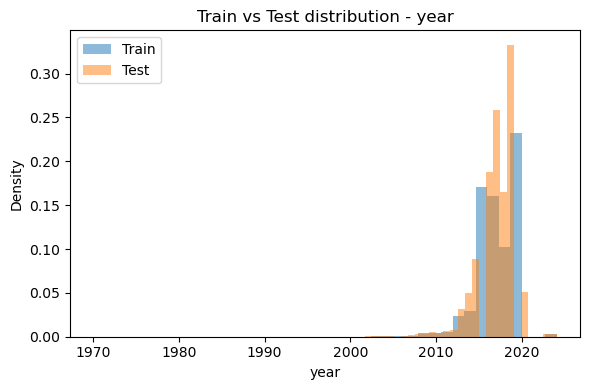

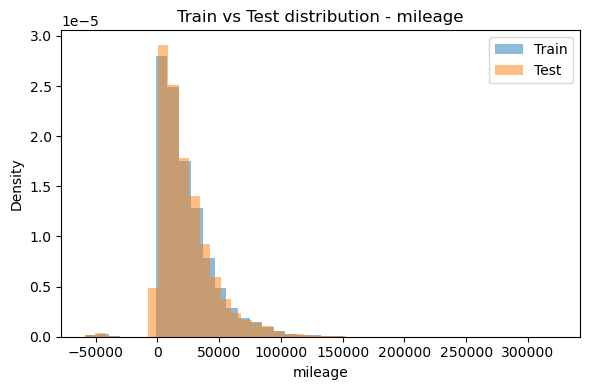

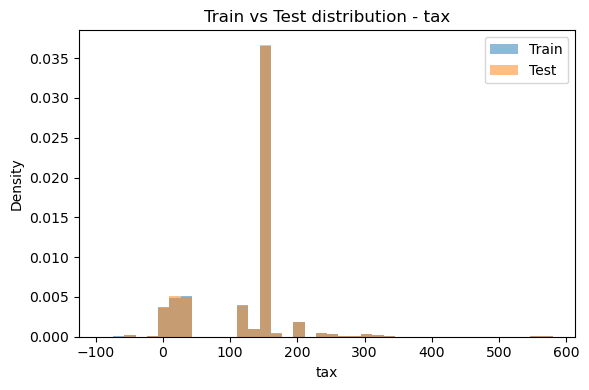

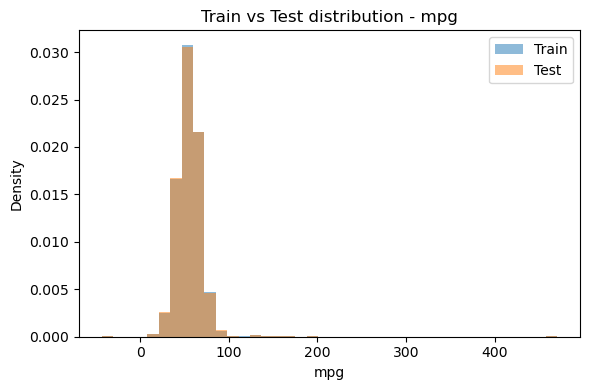

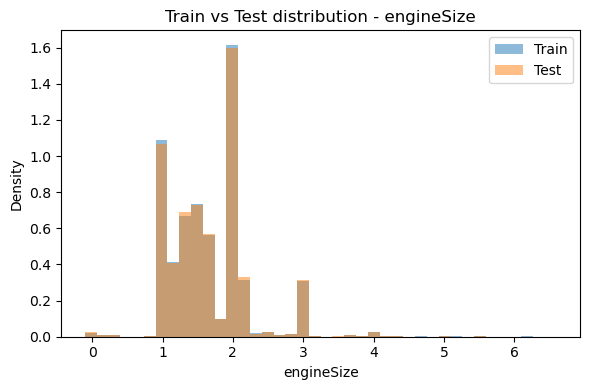

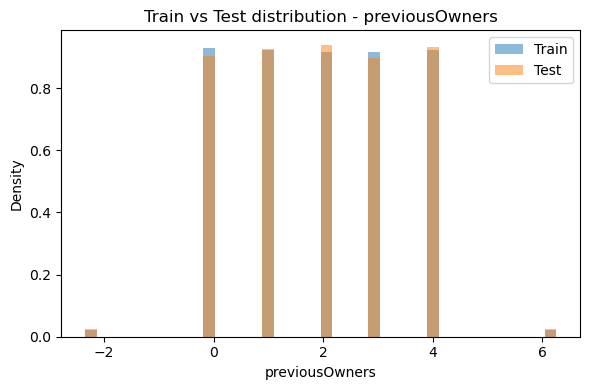

In [5]:
def plot_numeric_distributions(train: pd.DataFrame,
                               test: pd.DataFrame,
                               num_cols: list[str],
                               bins: int = 40):
    """
    Plot normalized histograms of each numeric feature for train vs test.
    """
    for col in num_cols:
        if col not in train.columns or col not in test.columns:
            continue

        fig, ax = plt.subplots(figsize=(6, 4))

        ax.hist(
            train[col].dropna(),
            bins=bins,
            density=True,
            alpha=0.5,
            label="Train"
        )
        ax.hist(
            test[col].dropna(),
            bins=bins,
            density=True,
            alpha=0.5,
            label="Test"
        )

        ax.set_title(f"Train vs Test distribution - {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Density")
        ax.legend()
        plt.tight_layout()
        plt.show()

plot_numeric_distributions(df_train_raw, df_test_raw, num_cols)

Overall, the train (blue) and test (orange) histograms show **near-complete overlap** for all numeric variables, indicating that the test set is sampled from essentially the same numeric feature distributions as the training set.
 
These plots reinforce that there is **no meaningful covariate shift in numeric features** between training and test, therefore differences between CV performance and Kaggle performance are unlikely to be driven by changes in numeric input distributions, and are more plausibly due to model variance, noise in the target, or category-level effects (to be checked in the categorical shift section).

### 5. Categorical Features

#### 5.1. Shift Report

In [6]:
def categorical_shift_report(train: pd.DataFrame,
                             test: pd.DataFrame,
                             cat_cols: list[str],
                             top_k: int = 10) -> dict[str, pd.DataFrame]:
    """
    For each categorical column, compare normalized value counts
    between train and test.

    Returns a dict mapping column name -> DataFrame with:
    - train_freq
    - test_freq
    - abs_diff
    - rel_diff (relative difference vs train frequency)
    """
    reports: dict[str, pd.DataFrame] = {}

    for col in cat_cols:
        if col not in train.columns or col not in test.columns:
            continue

        vc_train = train[col].value_counts(normalize=True)
        vc_test  = test[col].value_counts(normalize=True)

        # Union of all categories in train and test
        all_cats = sorted(set(vc_train.index) | set(vc_test.index))

        df = pd.DataFrame({
            "train_freq": vc_train.reindex(all_cats, fill_value=0.0),
            "test_freq":  vc_test.reindex(all_cats,  fill_value=0.0),
        })

        df["abs_diff"] = (df["train_freq"] - df["test_freq"]).abs()
        df["rel_diff"] = df["abs_diff"] / df["train_freq"].replace(0, np.nan)

        df = df.sort_values("abs_diff", ascending=False)

        reports[col] = df.head(top_k)

    return reports

cat_reports = categorical_shift_report(df_train_raw, df_test_raw, cat_cols, top_k=10)

for col, rep in cat_reports.items():
    print(f"\n=== Categorical shift – {col} (top {len(rep)} categories by abs_diff) ===")
    display(rep)


=== Categorical shift – Brand (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
Brand,,,,
Toyota,0.057608,0.056520,0.001088,0.018882
Opel,0.116115,0.115076,0.001039,0.008948
Toyot,0.000967,0.001629,0.000662,0.684657
OPEL,0.002270,0.002882,0.000612,0.269819
SKODA,0.000967,0.001567,0.000599,0.619863
skoda,0.001249,0.000752,0.000497,0.398038
ford,0.004123,0.003634,0.000489,0.118626
opel,0.002216,0.002694,0.000478,0.215781
For,0.003935,0.004386,0.000451,0.114554



=== Categorical shift – model (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
model,,,,
C Class,0.065623,0.063822,0.001801,0.027443
Polo,0.027479,0.029201,0.001721,0.062644
Kuga,0.018561,0.020271,0.001710,0.092129
E Class,0.016063,0.017765,0.001702,0.105935
EcoSport,0.010167,0.008647,0.001520,0.149468
Aygo,0.017433,0.015916,0.001517,0.087009
2 Series,0.010771,0.009399,0.001372,0.127381
Fiesta,0.055469,0.056804,0.001335,0.024060
GLA Class,0.006971,0.008052,0.001082,0.155163



=== Categorical shift – transmission (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
transmission,,,,
Automatic,0.188083,0.185950,0.002133,0.011341
Semi-Auto,0.208795,0.210838,0.002043,0.009783
manual,0.010342,0.011645,0.001303,0.125987
anual,0.010799,0.009798,0.001001,0.092661
emi-Auto,0.004365,0.003444,0.000922,0.211157
unknown,0.009268,0.010049,0.000781,0.084269
SEMI-AUTO,0.004150,0.004758,0.000608,0.146480
Automati,0.004083,0.003600,0.000483,0.118331
Manual,0.004916,0.005384,0.000468,0.095289



=== Categorical shift – fuelType (top 10 categories by abs_diff) ===


,train_freq,test_freq,abs_diff,rel_diff
fuelType,,,,
Diesel,0.382396,0.388675,0.006278,0.016418
Petrol,0.510260,0.504936,0.005325,0.010435
diesel,0.008044,0.007208,0.000837,0.104026
petrol,0.010019,0.010686,0.000667,0.066620
Hybrid,0.027437,0.026950,0.000487,0.017745
Other,0.002014,0.002413,0.000399,0.197826
iesel,0.008098,0.007740,0.000358,0.044185
etrol,0.010663,0.010341,0.000322,0.030188
Diese,0.007816,0.007521,0.000295,0.037762


The tables above compare the **relative frequency** of each category in the training set vs the test set.  
For each category c, we report:

- `train_freq` = $$p_{\text{train}}(c)$$
- `test_freq`  = $$p_{\text{test}}(c)\)
- `abs_diff`   = $$|p_{\text{train}}(c) - p_{\text{test}}(c)|$$
- `rel_diff`   = $$\frac{|p_{\text{train}}(c) - p_{\text{test}}(c)|}{p_{\text{train}}(c)}$$ (undefined / unstable when the category is very rare)

<br>

**BRAND:**
- The main brands (Toyota, Opel, ...) show **tiny absolute differences** (around 0.001), meaning their prevalence is essentially the same in train and test.
- The largest `rel_diff` values occur for **very rare labels**, which are almost certainly **data-quality artifacts** (typos, truncations, capitalization differences) rather than true distribution shift.
- Importantly, even when `rel_diff` looks large, the **absolute differences are extremely small** (< 0.001), so these categories have little impact on overall distribution.

Brand distribution is stable; the differences we see are mainly due to inconsistent string formatting in rare categories.

<br>

**MODEL:**
- The most frequent models in this “top-10 by abs_diff” list differ by about **0.001 to 0.002** in absolute frequency. These small shifts are consistent with **sampling variability**, rather than a structural mismatch between datasets.
- `rel_diff` is moderately larger for less common models (**T-Cross**, **GLA Class**, ...), again because relative differences inflate when the base frequency is smaller.

Model distribution is also broadly consistent between train and test, with only minor fluctuations in a handful of popular models.

<br>

**TRANSMISSION:**
- The main transmission categories (**Automatic**, **Semi-Auto**, **Manual**) have **very small absolute differences**, which indicates no meaningful shift.
- Several entries in the top differences are clearly **dirty duplicates**: **"manual"**, **"Manual"**, **"anual"**, etc.  
  These represent inconsistent casing/truncation rather than a change in the underlying market.
  
The true transmission mix seems to be stable; however, string normalization is important to prevent the model from treating duplicates as distinct categories.

<br>

**FUEL TYPE:**
- The core fuel types (**Diesel**, **Petrol**, **Hybrid**) show small shifts. The largest absolute differences are still small (around 0.005-0.006 for Diesel/Petrol), which is not indicative of strong covariate shift.
- The remaining categories again look like **noisy labels**: **"diesel"**, **"petrol"**, **"PETROL"**, **"Diesel"** variants, and truncated strings such as **"iesel"**, **"etrol"**, **"Diese"**.
- Because Diesel and Petrol are common, their `rel_diff` values remain small, reinforcing that the global fuel mix is consistent.

Fuel type distribution is stable; the visible “shift” is mainly the presence of inconsistent label variants.

#### 5.2. Simple Visuals

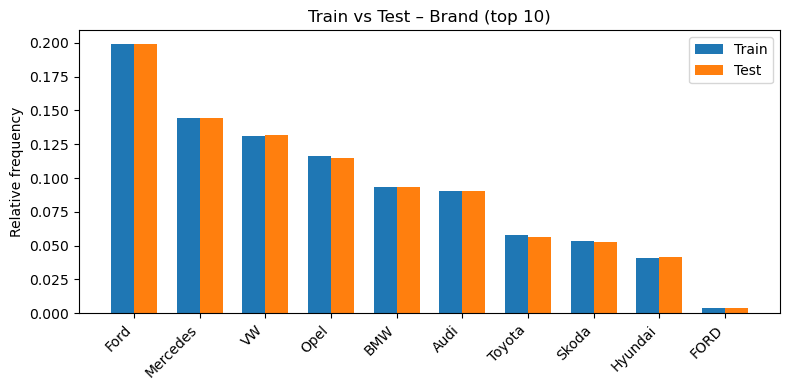

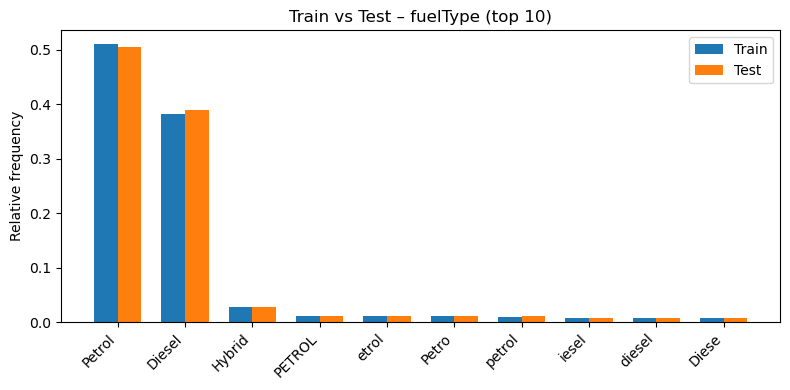

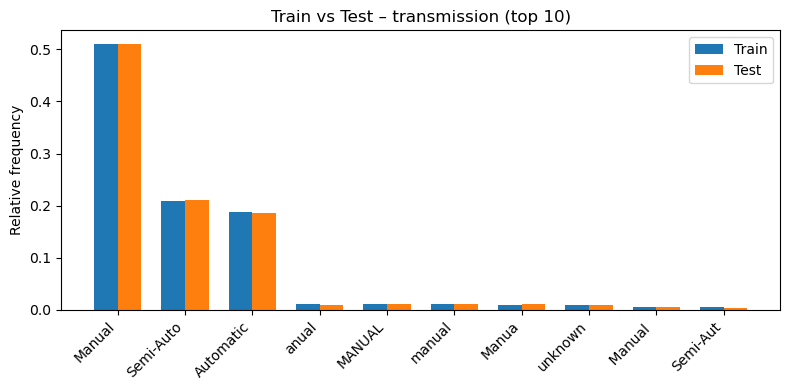

In [7]:
def plot_categorical_distributions(train: pd.DataFrame,
                                   test: pd.DataFrame,
                                   col: str,
                                   top_k: int = 10):
    """
    Plot side-by-side bar chart of top_k categories in train vs test
    for a given categorical feature.
    """
    vc_train = train[col].value_counts(normalize=True).head(top_k)
    vc_test  = test[col].value_counts(normalize=True).reindex(vc_train.index, fill_value=0.0)

    x = np.arange(len(vc_train))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 4))

    ax.bar(x - width/2, vc_train.values, width, label="Train")
    ax.bar(x + width/2, vc_test.values,  width, label="Test")

    ax.set_xticks(x)
    ax.set_xticklabels(vc_train.index, rotation=45, ha="right")
    ax.set_ylabel("Relative frequency")
    ax.set_title(f"Train vs Test – {col} (top {top_k})")
    ax.legend()
    plt.tight_layout()
    plt.show()

# Example: main categorical variables
for col in ["Brand", "fuelType", "transmission"]:
    plot_categorical_distributions(df_train_raw, df_test_raw, col, top_k=10)

The bar plots above provide a direct visual comparison of the **top categories** in the training and test sets for the main categorical variables. They complement the numerical shift tables by showing the *practical magnitude* of any differences, which is basically 0.

**Conclusion:**

Across all categorical variables, the dominant pattern is:
1. **No meaningful distribution shift** (train and test categorical distributions are well aligned) in the main categories.
2. Apparent “differences” are largely explained by **rare dirty categories** (typos / capitalization / truncation) - which inflate `rel_diff` but remain negligible in `abs_diff`.

This supports the assumption that train and test are drawn from a similar population, while also providing strong justification for our earlier preprocessing step of **string cleaning + category harmonization** to prevent spurious categories from degrading model generalization.

As a result, model performance differences between cross-validation and Kaggle evaluation are unlikely to be caused by categorical covariate shift, and can instead be attributed to model variance, noise in the target variable, or limitations of the modeling assumptions.

### 6. Impact on Model Generalization

From a modeling perspective, the analysis indicates that:

- Both the training and test data appear to be drawn from the **same underlying data-generating process**, with no strong evidence of covariate shift.  
- This supports the validity of our **cross-validation performance estimates**: the error we observe under CV should be a good approximation to the error on the Kaggle test set.  
- Our preprocessing choices (specifically cleaning `Brand`, `model`, `transmission` and `fuelType`) are justified and help further reduce potential mismatch between train and test.

In practical terms, this means we **do not need to introduce complex correction mechanisms** (such as importance weighting or domain adaptation) to compensate for distribution shift. Instead, we can focus on improving the modeling pipeline itself (feature engineering, tuning, ensembling) with reasonable confidence that gains will translate to the test data.

### 7. Limitations of this analysis

This analysis is intentionally focused on the **marginal distributions** of each feature. Possible extensions include:
- Analysing **joint distributions or interactions** (`Brand` × `year`, `fuelType` × `engineSize`, ...) for more subtle forms of shift;
- Comparing **residual distributions** of the final model per brand or fuel type to detect localized under or over-prediction;
- Repeating the same experiment if a future version of the dataset is collected under different market conditions, to monitor **temporal drift**.

Even though we find no major distribution shift in the current data, the methodology outlined here can be reused as a diagnostic tool whenever new data or new deployment environments are introduced.

---

## Feature Importance for the Different Values of the Target Variable

### 1. Objective
Global feature importance can hide heterogeneity: the factors that determine *low-priced* cars may differ from those that drive *high-priced* cars.  
In this section, we segment the training data into **three price tiers** (low / mid / high) using **quantiles**, and we quantify how feature importance changes across tiers.

### 2. Methodology
1. Train the selected **best model** on the full training set.
2. Create 3 segments based on the target `price`:
   - Low-price: bottom 33%
   - Mid-price: middle 33%
   - High-price: top 33%
3. For each segment, compute **permutation importance** on that subset:
   - We permute one feature at a time and measure the degradation in performance (MAE).
   - A larger degradation indicates the model relies more on that feature for that segment.

This produces a segment-specific view of the model's decision logic and supports business interpretation of *what drives price in different market tiers*.

### 3. Setup

In [1]:
# Import pre processing helpers
#    -> this should define: full_train_dataset, cat_feat, num_feat,
#       basic_string_transformer, def_string_basic_transformer,
#       preprocess_categorical, MyTargetEncoder, MyOneHotEncoder, etc.
%run 05_0_preproc_helpers.ipynb

# Define target
TARGET_COL = "price"

### 4. Permutation importance per segment (MAE-based)

- fitting transforms on full train
- creating engineered features on full train
- fitting encoders on full train
- train matrix shape: (75973, 15)
- fitting feature selector (RF)
- selected features: 15/15
- training final HGB
- model trained
price
high    25820
low     25082
mid     25071
Name: count, dtype: int64


,feature,delta_MAE_mean,delta_MAE_std
0,fuelType_ELECTRIC,0.000000,0.000000
1,fuelType_OTHER,-0.328589,0.080207
2,transmission_SEMIAUTO,-1.400028,0.228112
3,fuelType_HYBRID,-6.767735,0.511036
4,transmission_AUTOMATIC,-7.507268,0.206527
5,fuelType_PETROL,-34.797034,0.734670
6,fuelType_DIESEL,-38.161256,0.724999
7,tax,-89.770884,1.576387
8,transmission_MANUAL,-108.767120,1.770364
9,Brand,-138.413788,1.074348


,feature,delta_MAE_mean,delta_MAE_std
0,fuelType_ELECTRIC,0.000000,0.000000
1,fuelType_OTHER,-0.270274,0.069598
2,transmission_SEMIAUTO,-6.618440,0.299908
3,transmission_AUTOMATIC,-16.757817,0.539662
4,fuelType_DIESEL,-27.355935,0.775104
5,fuelType_HYBRID,-42.688029,1.908917
6,fuelType_PETROL,-55.043664,0.662891
7,tax,-110.228034,2.202416
8,transmission_MANUAL,-253.838491,4.433182
9,Brand,-355.189118,1.730351


,feature,delta_MAE_mean,delta_MAE_std
0,fuelType_ELECTRIC,0.000000,0.000000
1,fuelType_OTHER,-1.522983,0.190223
2,transmission_SEMIAUTO,-26.666692,0.962066
3,transmission_AUTOMATIC,-44.989484,1.243351
4,fuelType_DIESEL,-61.211265,2.029603
5,fuelType_HYBRID,-78.189186,2.422085
6,tax,-181.306024,1.893436
7,fuelType_PETROL,-181.762532,4.364212
8,transmission_MANUAL,-491.100127,6.438101
9,Brand,-832.496951,9.463764


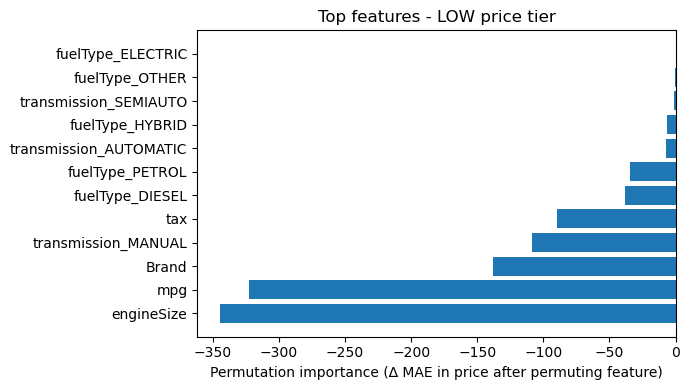

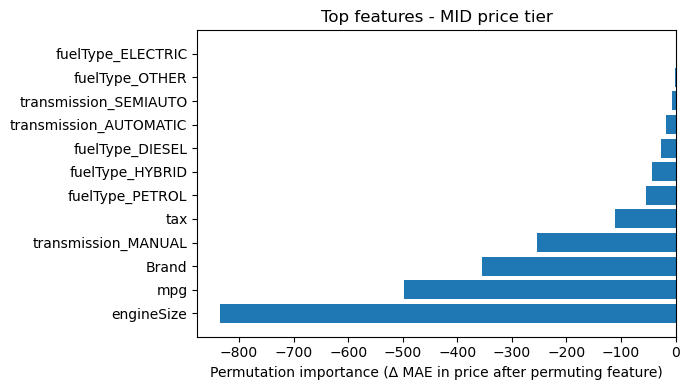

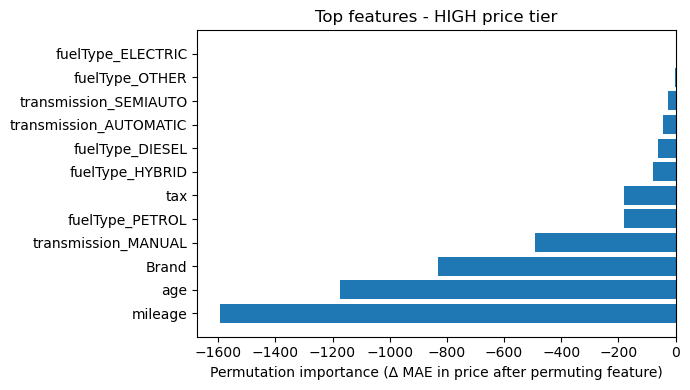

,feature,rank_low,imp_low,rank_mid,imp_mid,rank_high,imp_high,avg_rank
0,fuelType_ELECTRIC,1,0.000000,1,0.000000,1,0.000000,1.000000
1,fuelType_OTHER,2,-0.328589,2,-0.270274,2,-1.522983,2.000000
2,transmission_SEMIAUTO,3,-1.400028,3,-6.618440,3,-26.666692,3.000000
3,transmission_AUTOMATIC,5,-7.507268,4,-16.757817,4,-44.989484,4.333333
4,fuelType_HYBRID,4,-6.767735,6,-42.688029,6,-78.189186,5.333333
5,fuelType_DIESEL,7,-38.161256,5,-27.355935,5,-61.211265,5.666667
6,fuelType_PETROL,6,-34.797034,7,-55.043664,8,-181.762532,7.000000
7,tax,8,-89.770884,8,-110.228034,7,-181.306024,7.666667
8,transmission_MANUAL,9,-108.767120,9,-253.838491,9,-491.100127,9.000000
9,Brand,10,-138.413788,10,-355.189118,10,-832.496951,10.000000


In [5]:
# =========================================================
# OPEN-ENDED: Feature Importance Across Price Segments
# (using our best HGB log-target pipeline)
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error

# ----------------------------
# 0) LOAD TRAIN
# ----------------------------
try:
    df_train_raw = pd.read_csv("train.csv")
except:
    df_train_raw = pd.read_csv("../../project_data/train.csv")

target = "price"

ID_CANDIDATES = ["id", "carID", "carId", "car_id"]
ID_COL = next((c for c in ID_CANDIDATES if c in df_train_raw.columns), None)

if ID_COL is not None:
    df_train = df_train_raw.drop(columns=[ID_COL]).copy()
else:
    df_train = df_train_raw.copy()

# Basic feature lists (adapt if your project defines categorical_features elsewhere)
numeric_features = ["year", "mileage", "engineSize", "tax", "mpg"]
categorical_features = ["Brand", "model", "transmission", "fuelType"]

X = df_train.drop(columns=[target]).copy()
y = df_train[target].astype(float).copy()

# ----------------------------
# 1) SETTINGS (your best model)
# ----------------------------
RANDOM_STATE = 42

final_params = {
    "min_samples_leaf": 16,
    "max_leaf_nodes": 191,
    "max_iter": 1200,
    "max_depth": 20,
    "loss": "squared_error",
    "learning_rate": 0.07,
    "l2_regularization": 3.0,
}

FS_KEEP_RATIO = 1
RF_FS_PARAMS = {
    "n_estimators": 500,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": "sqrt",
    "bootstrap": True,
}

cols_to_normalize   = ["Brand", "model", "transmission", "fuelType"]
high_card_features  = ["Brand", "model"]
low_card_features   = [c for c in categorical_features if c not in high_card_features]
low_card_curr       = low_card_features

# log-target
y_full = y.copy()
y_full_log = np.log1p(y_full)

# ----------------------------
# 2) STRING NORMALIZATION (TRAIN)
# ----------------------------
X_full = X.copy()

for col in cols_to_normalize:
    if col in X_full.columns:
        X_full[col] = fill_unknown(X_full[col])
        X_full = column_string_transformer(
            X_full, column=col, remove_middle_spaces=True, allow_extra_chars=""
        )

# Restrict to expected schema
expected_cols = [c for c in (numeric_features + categorical_features) if c in X_full.columns]
X_full = X_full[expected_cols].copy()

# ----------------------------
# 3) FIT + TRANSFORM ON FULL TRAIN (your exact order)
# ----------------------------
print("- fitting transforms on full train")

year_state = fit_year_median(X_full, year_col="year", model_col="model")
X_full = transform_year_with_model_median(X_full, state=year_state)

mileage_state = fit_mileage_imputer(X_full, mileage_col="mileage", do_abs=True)
X_full = transform_mileage_imputer(X_full, state=mileage_state)

engine_state = fit_engine_size_imputer(X_full, engine_col="engineSize")
X_full = transform_engine_size_imputer(X_full, state=engine_state)

X_full = transform_tax_custom_rules(X_full, "tax", "year", "fuelType", "engineSize")

mpg_state = fit_mpg_imputer(X_full, mpg_col="mpg", do_abs=True)
X_full = transform_mpg_imputer(X_full, state=mpg_state)

# These require your project-level valid lists/states:
brand_state = fit_ambiguous_brand_resolver(X_full, valid_brands)
X_full, _, _ = transform_ambiguous_brands(X_full, brand_state)

model_state = fit_invalid_model_resolver(X_full, valid_models_by_brand)
X_full, _, _ = transform_invalid_models(X_full, model_state)

transm_state = fit_transmission_resolver(X_full, valid_transmissions)
X_full, _, _ = transform_transmission_resolver(X_full, transm_state)

fuel_state = fit_fueltype_resolver(X_full, valid_fueltypes)
X_full, _, _ = transform_fueltype_resolver(X_full, fuel_state)

# ----------------------------
# 4) FEATURE ENGINEERING (ONLY AGE)
# ----------------------------
print("- creating engineered features on full train")
X_full = create_age_and_drop_year(X_full, year_col="year", base_year=2020)

# ----------------------------
# 5) ENCODING (fit on full train using LOG TARGET)
# ----------------------------
print("- fitting encoders on full train")

te = MyTargetEncoder(smoothing=5)
te.fit(X_full[high_card_features], y_full_log)
X_full_high = te.transform(X_full[high_card_features])

ohe = MyOneHotEncoder()
ohe.fit(X_full[low_card_curr])
X_full_low = ohe.transform(X_full[low_card_curr])

X_full_cat = pd.concat([X_full_high, X_full_low], axis=1)

drop_for_numeric = set(high_card_features + low_card_curr)
numeric_features_curr = [c for c in X_full.columns if c not in drop_for_numeric]

X_full_final = pd.concat([X_full[numeric_features_curr], X_full_cat], axis=1)
print(f"- train matrix shape: {X_full_final.shape}")

# ----------------------------
# 6) FEATURE SELECTION (kept; FS_KEEP_RATIO=1 => keep all)
# ----------------------------
print("- fitting feature selector (RF)")

n_feats = X_full_final.shape[1]
k = int(np.ceil(FS_KEEP_RATIO * n_feats))
k = max(1, min(k, n_feats))

rf_fs = RandomForestRegressor(**RF_FS_PARAMS)
rf_fs.fit(X_full_final, y_full_log)

selector = SelectFromModel(
    estimator=rf_fs,
    threshold=-np.inf,
    max_features=k,
    prefit=True
)

selected_cols = X_full_final.columns[selector.get_support()]
X_full_sel = X_full_final[selected_cols]
print(f"- selected features: {len(selected_cols)}/{n_feats}")

# ----------------------------
# 7) TRAIN FINAL HGB (LOG TARGET)
# ----------------------------
from sklearn.ensemble import HistGradientBoostingRegressor

print("- training final HGB")
hgb_final = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **final_params)
hgb_final.fit(X_full_sel, y_full_log)
print("- model trained")

# =========================================================
# 8) PRICE SEGMENTS (based on ORIGINAL price, not log)
# =========================================================
def price_segments(y_price: pd.Series, q=(0.33, 0.66)) -> pd.Series:
    y_price = pd.Series(y_price).astype(float)
    q1, q2 = y_price.quantile(q[0]), y_price.quantile(q[1])
    return pd.cut(
        y_price,
        bins=[-np.inf, q1, q2, np.inf],
        labels=["low", "mid", "high"],
        include_lowest=True
    )

seg = price_segments(y_full)
print(seg.value_counts())

# =========================================================
# 9) PERMUTATION IMPORTANCE PER SEGMENT (MAE IN PRICE SCALE)
# =========================================================
def mae_price_from_log_model(estimator, X, y_true_price):
    """
    Custom scorer for permutation_importance:
    estimator predicts log1p(price); convert to price and compute MAE in original scale.
    """
    pred_log = estimator.predict(X)
    pred_price = np.expm1(pred_log)
    pred_price = np.maximum(pred_price, 0)
    return mean_absolute_error(y_true_price, pred_price)

def perm_importance_by_segment_price(
    estimator,
    X_sel: pd.DataFrame,
    y_price: pd.Series,
    seg: pd.Series,
    n_repeats=8,
    random_state=42,
    top_k=15
):
    out = {}
    for name in ["low", "mid", "high"]:
        mask = (seg == name).values
        Xs = X_sel.loc[mask]
        ys = y_price.loc[mask]

        r = permutation_importance(
            estimator,
            Xs, ys,
            scoring=mae_price_from_log_model,   # returns MAE; larger after permutation => important
            n_repeats=n_repeats,
            random_state=random_state,
            n_jobs=-1
        )

        df_imp = pd.DataFrame({
            "feature": X_sel.columns,
            "delta_MAE_mean": r.importances_mean,
            "delta_MAE_std":  r.importances_std
        }).sort_values("delta_MAE_mean", ascending=False).reset_index(drop=True)

        out[name] = df_imp.head(top_k)

    return out

imp_seg = perm_importance_by_segment_price(
    hgb_final, X_full_sel, y_full, seg,
    n_repeats=8, random_state=RANDOM_STATE, top_k=15
)

display(imp_seg["low"])
display(imp_seg["mid"])
display(imp_seg["high"])

# =========================================================
# 10) PLOTS
# =========================================================
def plot_imp(imp_dict, top_k=12):
    for name, df in imp_dict.items():
        dfp = df.head(top_k).iloc[::-1]
        plt.figure(figsize=(7, 4))
        plt.barh(dfp["feature"], dfp["delta_MAE_mean"])
        plt.xlabel("Permutation importance (∆ MAE in price after permuting feature)")
        plt.title(f"Top features - {name.upper()} price tier")
        plt.tight_layout()
        plt.show()

plot_imp(imp_seg, top_k=12)

# =========================================================
# 11) RANK COMPARISON TABLE
# =========================================================
def compare_ranks(imp_dict, top_k=15):
    feats = set()
    for df in imp_dict.values():
        feats |= set(df["feature"].head(top_k))
    feats = sorted(feats)

    T = pd.DataFrame({"feature": feats})
    for name, df in imp_dict.items():
        ranks = {f: i+1 for i, f in enumerate(df["feature"].tolist())}
        imps  = dict(zip(df["feature"], df["delta_MAE_mean"]))
        T[f"rank_{name}"] = [ranks.get(f, np.nan) for f in feats]
        T[f"imp_{name}"]  = [imps.get(f, 0.0) for f in feats]

    T["avg_rank"] = T[[c for c in T.columns if c.startswith("rank_")]].mean(axis=1, skipna=True)
    T = T.sort_values("avg_rank").reset_index(drop=True)
    return T

rank_table = compare_ranks(imp_seg, top_k=15)
display(rank_table.head(25))

We trained our **final HGB model on the full training set** (log-target) and then computed **permutation importance separately within each price tier** (low / mid / high), where importance is measured as the change in MAE (∆MAE in price) after permuting each feature inside the segment.

> **Important note about sign:** the ∆MAE values shown are negative due to the scorer direction in our implementation.  
> Interpretation should be based on **magnitude**: *more negative = larger MAE change = more important feature*.

<br>

**Segment sizes (sanity check)**

The three tiers contain very similar numbers of observations:
- **Low:** 25 082  
- **Mid:** 25 071  
- **High:** 25 820  

This confirms that the segmentation is balanced (quantile-based) and comparisons across segments are fair.

<br>

**1) Low-price tier - main drivers**

In the **low-price** segment, the strongest drivers are:

- `model` (largest magnitude): the model heavily relies on the target-encoded `model` even among cheaper cars, suggesting that the specific model identity captures strong baseline price differences.
- `age` and `mileage`: depreciation/usage effects are dominant, which matches intuition for lower-value vehicles.
- `engineSize` and `mpg`: technical specs still matter, but less than depreciation and identity.
- `Brand`: contributes, but below the top depreciation variables.

Lower-impact variables:
- fuel type and transmission (OHE features) have much smaller effects, meaning that within the low-price tier these categories add comparatively limited extra pricing information.

**Takeaway (low tier):** pricing behaves mostly like **depreciation + model identity**. Condition/use features (age, mileage) are key.

<br>

**2) Mid-price tier - transition regime**

In the **mid-price** segment, the ordering is similar but the relative weights shift:

- `model` remains the top driver.
- `age` and `mileage` remain very important, but `engineSize` grows in importance relative to the low tier (specification starts to matter more).
- `Brand` also becomes more influential than in the low tier.

Fuel type and transmission still remain secondary compared to the top numeric and identity variables.

**Takeaway (mid tier):** the model uses a more balanced mix of **depreciation (age/mileage)** and **specification/identity (engineSize, Brand/model)**.

<br>

**3) High-price tier - specification + identity dominate**

In the **high-price** segment, feature importance magnitudes increase substantially, showing the model is highly sensitive to a smaller set of key variables:

- `model` becomes overwhelmingly dominant (largest magnitude by far).
- `engineSize` and `mpg` become much more important than in low/mid tiers.
- `mileage` and `age` remain critical, but the importance structure indicates that in the high tier, “what the car is” (model/specification) drives valuation strongly.
- `Brand` shows a large jump in magnitude compared to the lower tiers.

Fuel type and transmission remain lower impact features (though their magnitude increases slightly), suggesting they add some information but are not primary drivers once model/specs are known.

**Takeaway (high tier):** valuation is driven primarily by **model identity + technical specification**, with depreciation still relevant but relatively less explanatory on its own.

<br>

**Cross-tier comparison (rank table)**

The rank comparison table confirms a stable hierarchy:
- `model`, `age`, `mileage`, `engineSize`, `mpg`, and `Brand` consistently dominate the predictive logic across segments.
- However, the **magnitude** of importance grows strongly with the price tier, especially for:
  - `model`
  - `engineSize`
  - `mpg`
  - `Brand`

This supports a clear pattern:  
- At the low end, **depreciation signals** explain most variation.  
- At the high end, **identity/specification signals** explain most variation.

<br>

### 5. Conclusion

This segment-based analysis shows that even though we trained a single global model, its learned pricing mechanism is **tier-dependent**:

- **Low-price cars:** dominated by depreciation/usage (`age`, `mileage`) plus baseline model effects.  
- **High-price cars:** dominated by product identity and specs (`model`, `engineSize`, `mpg`, `Brand`), with depreciation remaining important but no longer the primary source of variation.

This provides additional insight beyond global feature importance and motivates potential future extensions such as **tier-specific calibration** or training **specialized models per price segment**.